# Notebook 00: Data Exploration

## Goal
Get eyes on all three data sources before building anything.
- MedQA USMLE (JSONL, 4-option clinical vignettes)
- MedMCQA (Parquet, short factual questions with subject labels)
- Medical textbooks (18 plain .txt files)

No modelling here! Just shapes, samples, and sanity checks.

## 0. Setup

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

from src.data import (
    load_medqa,
    load_medqa_all,
    load_medmcqa,
    load_all_textbooks,
    textbooks_as_dataframe,
    REPO_ROOT,
)

print(f'Repo root: {REPO_ROOT}')

Repo root: /home/jaxen/uO/emma


## 1. MedQA USMLE

In [16]:
# Load a small slice first just to see the shape
medqa_train = load_medqa(split='train', n=20)
medqa_train.head(3)

[MedQA] Loaded 20 rows  (split=train)


,question,options,answer_idx,answer,meta_phrases
0,A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day...,"{'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': 'Doxycycline', 'D': 'Nitrofurantoin'}",D,Nitrofurantoin,"[23 year old pregnant woman, weeks presents, burning, urination, states, started 1 day, worsening, drinking, water, ..."
1,A 3-month-old baby died suddenly at night while asleep. His mother noticed that he had died only after she awoke in ...,"{'A': 'Placing the infant in a supine position on a firm mattress while sleeping', 'B': 'Keeping the infant covered ...",A,Placing the infant in a supine position on a firm mattress while sleeping,"[3 month old baby died, night, asleep, mother, died only, awoke in, morning, cause of death, based, autopsy, followi..."
2,A mother brings her 3-week-old infant to the pediatrician's office because she is concerned about his feeding habits...,"{'A': 'Abnormal migration of ventral pancreatic bud', 'B': 'Complete failure of proximal duodenum to recanalize', 'C...",A,Abnormal migration of ventral pancreatic bud,"[mother, week old infant, pediatrician's office, concerned, feeding habits, born, complications, not, medical proble..."


In [17]:
# Print one full question so we can see the vignette style
row = medqa_train.iloc[0]
print('QUESTION:')
print(row['question'])
print('\nOPTIONS:')
for k, v in row['options'].items():
    marker = ' ←' if k == row['answer_idx'] else ''
    print(f'  {k}) {v}{marker}')
print(f'\nMetaMap phrases: {row["meta_phrases"]}')

QUESTION:
A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?

OPTIONS:
  A) Ampicillin
  B) Ceftriaxone
  C) Doxycycline
  D) Nitrofurantoin ←

MetaMap phrases: ['23 year old pregnant woman', 'weeks presents', 'burning', 'urination', 'states', 'started 1 day', 'worsening', 'drinking', 'water', 'taking cranberry extract', 'feels well', 'followed by', 'doctor', 'pregnancy', 'temperature', '97', '36', 'blood pressure', 'mmHg', 'pulse', '80 min', 'respirations', 'min

In [18]:
# Load all splits and check sizes
medqa_all = load_medqa_all()
print(medqa_all.groupby('split').size())
print(f'\nTotal: {len(medqa_all):,} questions')

[MedQA] Loaded 10,178 rows  (split=train)
[MedQA] Loaded 1,272 rows  (split=dev)
[MedQA] Loaded 1,273 rows  (split=test)
split
dev       1272
test      1273
train    10178
dtype: int64

Total: 12,723 questions


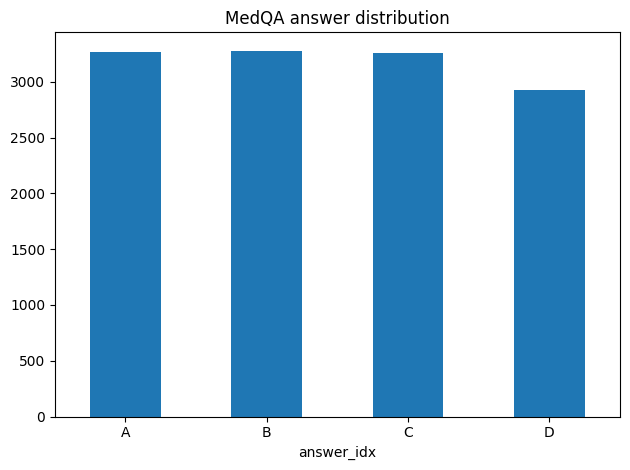

In [19]:
# Check answer distribution (should be roughly balanced across A/B/C/D)
medqa_all['answer_idx'].value_counts().sort_index().plot(
    kind='bar', title='MedQA answer distribution', rot=0
)
plt.tight_layout()
plt.show()

In [20]:
# Question length distribution
medqa_all['q_len'] = medqa_all['question'].str.len()
medqa_all['q_len'].describe().round(1)

count    12723.0
mean       726.3
std        278.7
min         66.0
25%        529.0
50%        697.0
75%        894.0
max       3577.0
Name: q_len, dtype: float64

## 2. MedMCQA

In [21]:
mcqa_train = load_medmcqa(split='train', n=20)
mcqa_train.head(3)

[MedMCQA] Loaded 20 rows  (split=train)


,id,question,opa,opb,opc,opd,cop,choice_type,exp,subject_name,topic_name,answer
0,e9ad821a-c438-4965-9f77-760819dfa155,Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma,Hyperplasia,Hyperophy,Atrophy,Dyplasia,2,single,"Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnancy, tumors, uter...",Anatomy,Urinary tract,Atrophy
1,e3d3c4e1-4fb2-45e7-9f88-247cc8f373b3,Which vitamin is supplied from only animal source:,Vitamin C,Vitamin B7,Vitamin B12,Vitamin D,2,single,Ans. (c) Vitamin B12 Ref: Harrison's 19th ed. P 640* Vitamin B12 (Cobalamin) is synthesized solely by microorganisms...,Biochemistry,Vitamins and Minerals,Vitamin B12
2,5c38bea6-787a-44a9-b2df-88f4218ab914,All of the following are surgical options for morbid obesity except -,Adjustable gastric banding,Biliopancreatic diversion,Duodenal Switch,Roux en Y Duodenal By pass,3,multi,"Ans. is 'd' i.e., Roux en Y Duodenal Bypass Bariatric surgical procedures include:a. Vertical banded gastroplastyb. ...",Surgery,Surgical Treatment Obesity,Roux en Y Duodenal By pass


In [22]:
# Print one question
row = mcqa_train.iloc[0]
print('QUESTION:', row['question'])
option_cols = ['opa', 'opb', 'opc', 'opd']
for i, col in enumerate(option_cols):
    marker = ' ←' if i == int(row['cop']) else ''
    print(f'  {"ABCD"[i]}) {row[col]}{marker}')
print(f'\nSubject: {row.get("subject_name")}  |  Topic: {row.get("topic_name")}')

QUESTION: Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma
  A) Hyperplasia
  B) Hyperophy
  C) Atrophy ←
  D) Dyplasia

Subject: Anatomy  |  Topic: Urinary tract


[MedMCQA] Loaded 182,822 rows  (split=train)
Total train rows: 182,822


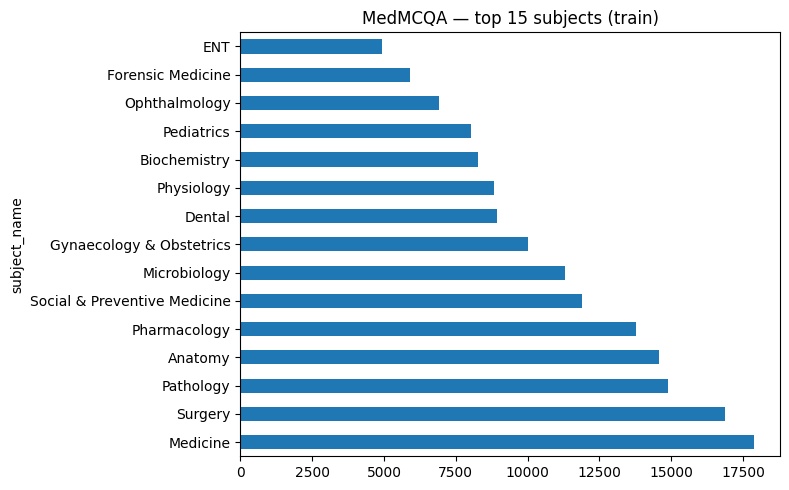

In [23]:
# Load full train set and check subject distribution
mcqa_full = load_medmcqa(split='train')
print(f'Total train rows: {len(mcqa_full):,}')

# Top 15 subjects
subj = mcqa_full['subject_name'].value_counts().head(15)
subj.plot(kind='barh', title='MedMCQA — top 15 subjects (train)', figsize=(8, 5))
plt.tight_layout()
plt.show()

In [24]:
# Validation and test sizes
for split in ['validation', 'test']:
    df = load_medmcqa(split=split)
    print(f'{split}: {len(df):,} rows')

[MedMCQA] Loaded 4,183 rows  (split=validation)
validation: 4,183 rows
[MedMCQA] Loaded 6,150 rows  (split=test)
test: 6,150 rows


## 3. Medical textbooks

In [25]:
tb_df = textbooks_as_dataframe()
tb_df[['friendly_name', 'char_count']].sort_values('char_count', ascending=False)

  ✓  Gray's Anatomy  (2,281,157 chars)
  ✓  Lippincott Biochemistry  (1,349,616 chars)
  ✓  Alberts Cell Biology  (4,868,257 chars)
  ✓  First Aid Step 1  (665,018 chars)
  ✓  First Aid Step 2  (1,030,582 chars)
  ✓  Novak's Gynecology  (5,619,750 chars)
  ✓  Ross Histology  (3,047,020 chars)
  ✓  Janeway's Immunology  (3,315,092 chars)
  ✓  Harrison's Internal Medicine  (22,312,859 chars)
  ✓  Adams Neurology  (8,365,987 chars)
  ✓  Williams Obstetrics  (6,583,361 chars)
  ✓  Robbins Pathology  (3,784,898 chars)
  ✓  Pathoma (Husain)  (399,834 chars)
  ✓  Nelson Pediatrics  (3,002,297 chars)
  ✓  Katzung Pharmacology  (5,122,267 chars)
  ✓  Levy Physiology  (3,049,236 chars)
  ✓  DSM-5 Psychiatry  (2,893,358 chars)
  ✓  Schwartz Surgery  (11,441,715 chars)

[Textbooks] Loaded 18 books total


,friendly_name,char_count
8,Harrison's Internal Medicine,22312859
17,Schwartz Surgery,11441715
9,Adams Neurology,8365987
10,Williams Obstetrics,6583361
5,Novak's Gynecology,5619750
14,Katzung Pharmacology,5122267
2,Alberts Cell Biology,4868257
11,Robbins Pathology,3784898
7,Janeway's Immunology,3315092
15,Levy Physiology,3049236


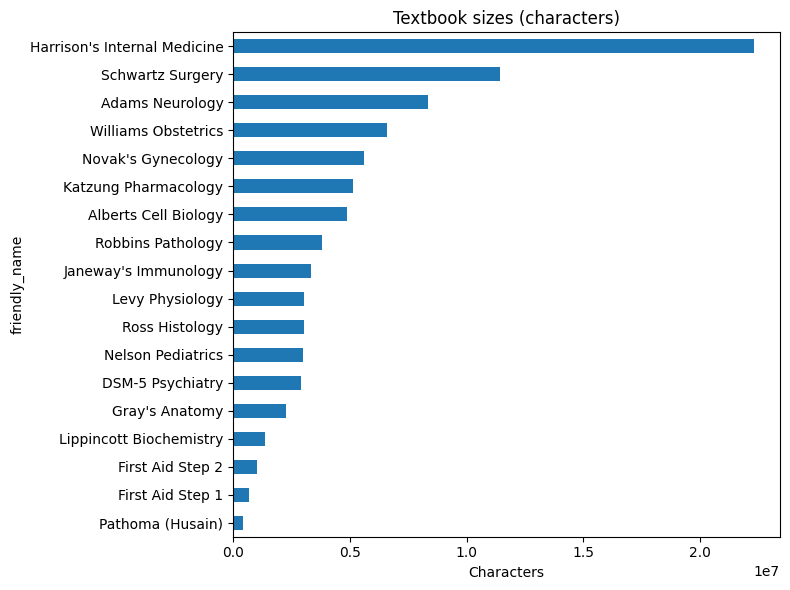

In [26]:
# Bar chart of textbook sizes
ax = tb_df.sort_values('char_count').plot(
    kind='barh', x='friendly_name', y='char_count',
    figsize=(8, 6), title='Textbook sizes (characters)', legend=False
)
ax.set_xlabel('Characters')
plt.tight_layout()
plt.show()

In [27]:
# Preview 500 chars from Harrison's
books = load_all_textbooks()
print(books['InternalMed_Harrison'][:500])

  ✓  Gray's Anatomy  (2,281,157 chars)
  ✓  Lippincott Biochemistry  (1,349,616 chars)
  ✓  Alberts Cell Biology  (4,868,257 chars)
  ✓  First Aid Step 1  (665,018 chars)
  ✓  First Aid Step 2  (1,030,582 chars)
  ✓  Novak's Gynecology  (5,619,750 chars)
  ✓  Ross Histology  (3,047,020 chars)
  ✓  Janeway's Immunology  (3,315,092 chars)
  ✓  Harrison's Internal Medicine  (22,312,859 chars)
  ✓  Adams Neurology  (8,365,987 chars)
  ✓  Williams Obstetrics  (6,583,361 chars)
  ✓  Robbins Pathology  (3,784,898 chars)
  ✓  Pathoma (Husain)  (399,834 chars)
  ✓  Nelson Pediatrics  (3,002,297 chars)
  ✓  Katzung Pharmacology  (5,122,267 chars)
  ✓  Levy Physiology  (3,049,236 chars)
  ✓  DSM-5 Psychiatry  (2,893,358 chars)
  ✓  Schwartz Surgery  (11,441,715 chars)

[Textbooks] Loaded 18 books total
xxxviii its related products in new formats. Kim Davis, as Associate Managing We are privileged to have compiled this 19th edition and areEditor, has adeptly ensured that the complex production of 

# 4. Summary

In [ ]:
medqa_counts = medqa_all["split"].value_counts()
fmt = lambda n: f"{int(n):,}"

summary_df = pd.DataFrame([
    {"Dataset": "MedQA train",   "Rows": fmt(medqa_counts.get("train", 0)), "Notes": ""},
    {"Dataset": "MedQA dev",     "Rows": fmt(medqa_counts.get("dev", medqa_counts.get("validation", 0))), "Notes": ""},
    {"Dataset": "MedQA test",    "Rows": fmt(medqa_counts.get("test", 0)), "Notes": ""},
    {"Dataset": "MedMCQA train", "Rows": fmt(len(mcqa_full)), "Notes": ""},
    {"Dataset": "MedMCQA val",   "Rows": fmt(len(load_medmcqa(split="validation"))), "Notes": ""},
    {"Dataset": "MedMCQA test",  "Rows": fmt(len(load_medmcqa(split="test"))), "Notes": ""},
    {"Dataset": "Textbooks",     "Rows": fmt(len(tb_df)), "Notes": f"Total chars: {tb_df['char_count'].sum():,}"},
])

display(summary_df)


[MedMCQA] Loaded 4,183 rows  (split=validation)
[MedMCQA] Loaded 6,150 rows  (split=test)


,Dataset,Rows,Notes
0,MedQA train,"10,178",
1,MedQA dev,"1,272",
2,MedQA test,"1,273",
3,MedMCQA train,"182,822",
4,MedMCQA val,"4,183",
5,MedMCQA test,"6,150",
6,Textbooks,18,"Total chars: 89,132,304"
